In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os

directorio_actual = os.getcwd()
abspath = os.path.abspath(os.path.join(directorio_actual, '..'))

if abspath not in sys.path:
    sys.path.append(abspath)

from Practica_1.runner import ejecutar_experimento
from Practica_3.runner import (
    ejecutar_experimento_ga,
    ejecutar_tabla_parcial,
    ejecutar_analisis_cajas_p3,
    ejecutar_estudio_parametrico,
    mostrar_soluciones_multimodal,
)
from Practica_3.utils import generar_tabla_global_p3

### **Algoritmo de comparación 1: Greedy**

In [3]:
res_greedy = ejecutar_experimento(
    id_algoritmo='greedy',
    maps=False
)


 EXPERIMENTACIÓN: GREEDY ALGORITHM
| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) |      Semilla      | Mejor FObj |
---------------------------------------------------------------------------------------------------------------------
| Caso 1 |      1.5485 |   23.68 |  15.2903 |      1.0 |         1 |       0.0001 |               N/A | ratio      |
| Caso 2 |      1.6087 |   23.77 |  14.7736 |      1.0 |         1 |       0.0001 |               N/A | ratio      |
| Caso 3 |      2.4834 |   23.24 |   9.3560 |      1.0 |         1 |       0.0001 |               N/A | ratio      |
---------------------------------------------------------------------------------------------------------------------


### **Algoritmo de comparación 2: Búsqueda Local Primer Mejor (P.Mejor)**


 EXPERIMENTACIÓN: BÚSQUEDA LOCAL (PRIMER MEJOR)
| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media| Ev. Mejor | T. Medio (s) |      Semilla      | Mejor FObj |
---------------------------------------------------------------------------------------------------------------------
| Caso 1 |      1.5410 |   23.87 |  15.4872 |    333.6 |       348 |       0.0052 |           4192853 | ratio      |
| Caso 2 |      1.5801 |   25.03 |  15.8404 |    311.7 |       358 |       0.0043 |            382941 | insatisfac |
| Caso 3 |      2.1990 |   25.42 |  11.5598 |    377.0 |       382 |       0.0051 |          27849102 | suma_ponde |
---------------------------------------------------------------------------------------------------------------------


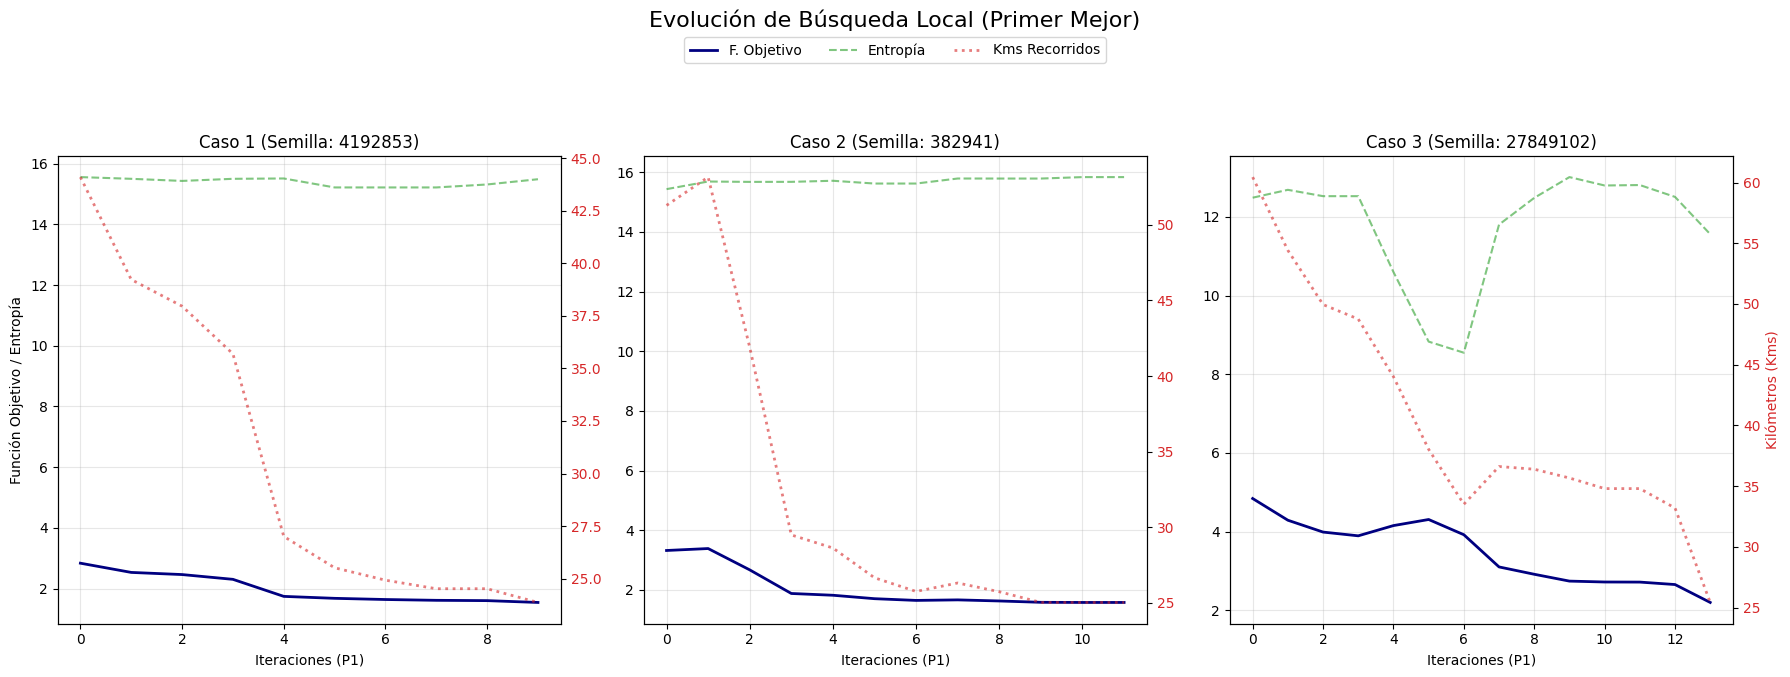

In [4]:
res_primer_mejor = ejecutar_experimento(
    id_algoritmo='local_primer_mejor',
    max_evals=3000,
    maps=False
)

### **Experimento 1: Algoritmo Genético Básico**

Generacional con elitismo, población de 30 individuos, selección por torneo (K=10%), cruce OX al 90% y, cuando no hay cruce, mutación 2-opt (5-10%).


 EXPERIMENTACIÓN: AG BÁSICO
| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media | Ev. Mejor | T. Medio(s)|   Semilla    | Mejor FObj |
---------------------------------------------------------------------------------------------------------------
| Caso 1 |      1.3591 |   20.93 |  15.4031 |    3000.0 |      3000 |     0.0553 |      4192853 | ratio_cuad |
| Caso 2 |      1.4277 |   22.69 |  15.8888 |    3000.0 |      3000 |     0.0555 |       382941 | ratio      |
| Caso 3 |      2.0817 |   24.39 |  11.7142 |    3000.0 |      3000 |     0.0570 |   1842910337 | exponencia |
---------------------------------------------------------------------------------------------------------------


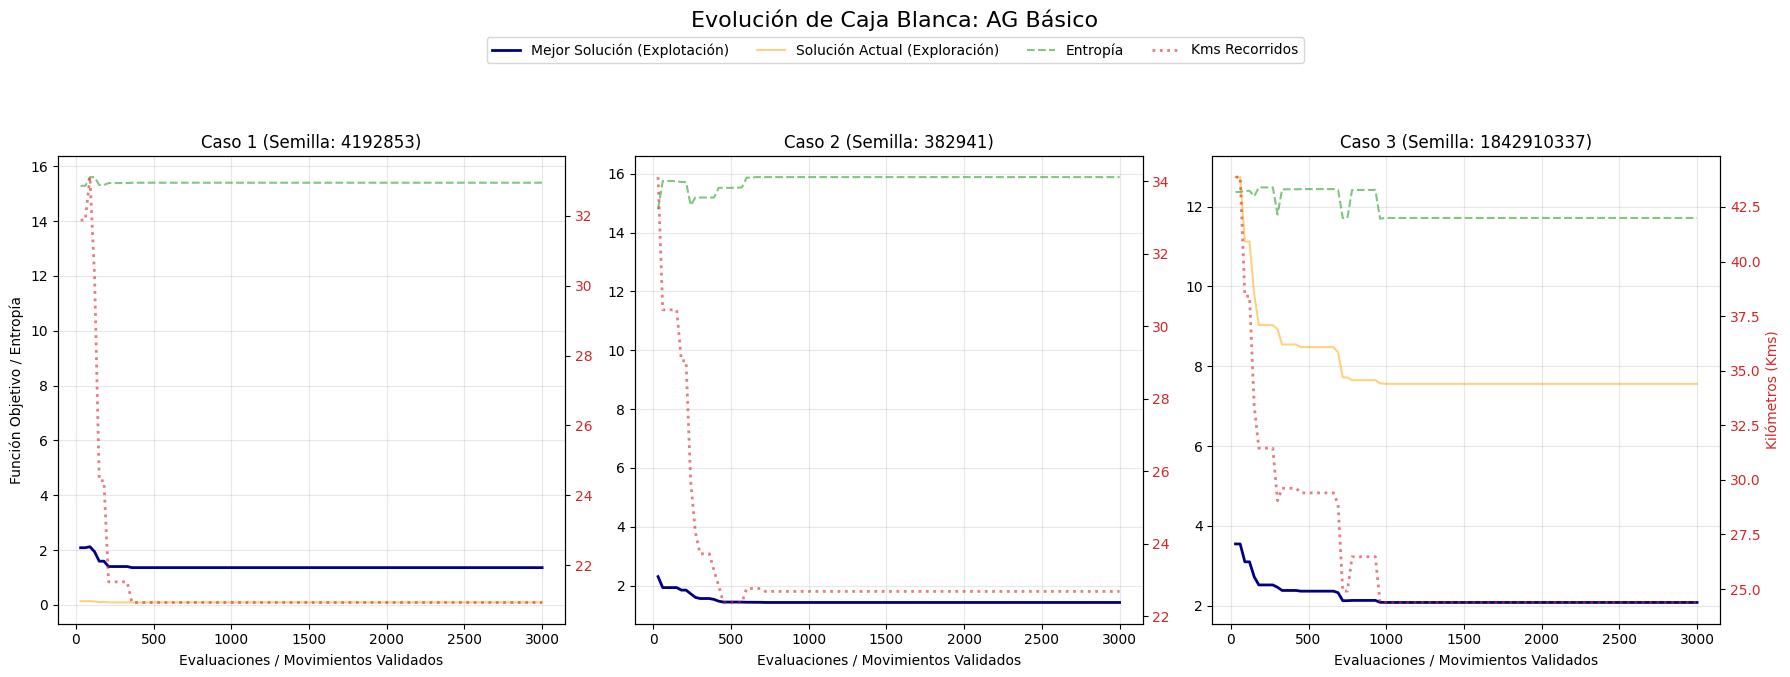

In [5]:
res_basico = ejecutar_experimento_ga(
    id_algoritmo='basico',
    maps=False
)

### **Experimento 2: Algoritmo Genético CHC**

Prevención de incesto con distancia de Hamming por **arcos** (umbral inicial L/4), recombinación HUX adaptada a orden, supervivencia elitista sin mutación y reinicios al converger el umbral.


 EXPERIMENTACIÓN: AG CHC
| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media | Ev. Mejor | T. Medio(s)|   Semilla    | Mejor FObj |
---------------------------------------------------------------------------------------------------------------
| Caso 1 |      1.3576 |   20.93 |  15.4210 |    3000.5 |      3000 |     0.0567 |      4192853 | ratio      |
| Caso 2 |      1.4277 |   22.69 |  15.8888 |    3001.3 |      3002 |     0.0564 |   1842910337 | suma_ponde |
| Caso 3 |      2.0116 |   23.42 |  11.6435 |    3001.7 |      3000 |     0.0583 |     27849102 | suma_ponde |
---------------------------------------------------------------------------------------------------------------

 --- Parámetros Específicos ---
 - Caso 1: reinicios=4, umbral_ini=3
 - Caso 2: reinicios=5, umbral_ini=3
 - Caso 3: reinicios=4, umbral_ini=3


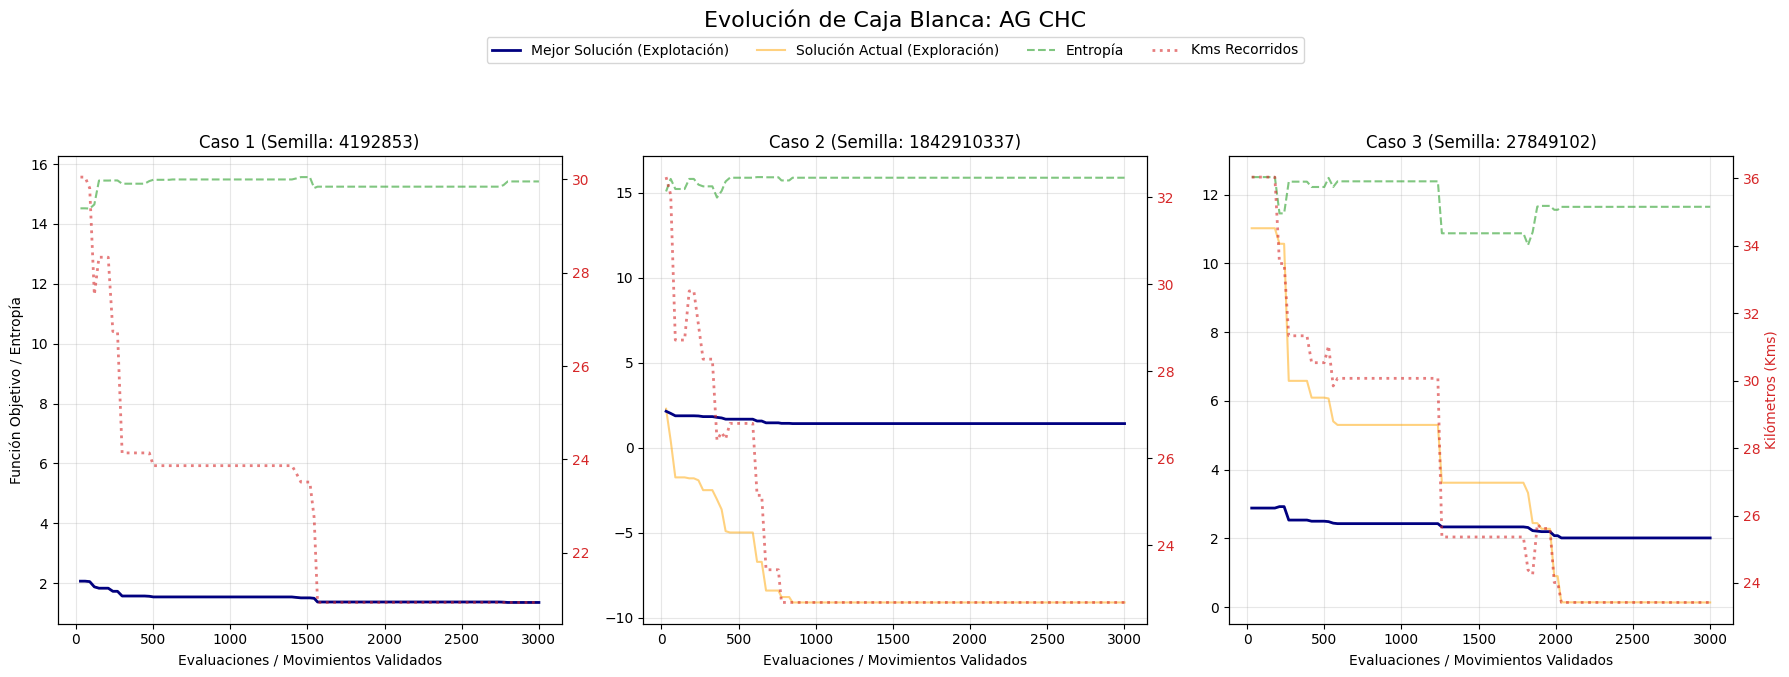

In [6]:
res_chc = ejecutar_experimento_ga(
    id_algoritmo='chc',
    maps=False
)

### **Experimento 3: Algoritmo Genético Multimodal (Clearing)**

AG Básico + **Clearing**: el radio del nicho se mide con la distancia de Hamming por arcos; cada generación se conservan los dominantes y se penaliza al resto.


 EXPERIMENTACIÓN: AG MULTIMODAL (CLEARING)
| Caso   | Score (Ratio)| Kms     | Entropía | Ev. Media | Ev. Mejor | T. Medio(s)|   Semilla    | Mejor FObj |
---------------------------------------------------------------------------------------------------------------
| Caso 1 |      1.3576 |   20.93 |  15.4210 |    3000.0 |      3000 |     0.1466 |   1842910337 | suma_ponde |
| Caso 2 |      1.4377 |   22.69 |  15.7793 |    3000.0 |      3000 |     0.1463 |     27849102 | ratio      |
| Caso 3 |      2.0268 |   23.74 |  11.7122 |    3000.0 |      3000 |     0.1507 |     27849102 | suma_ponde |
---------------------------------------------------------------------------------------------------------------

 --- Parámetros Específicos ---
 - Caso 1: sigma=3, capacidad_nicho=1
 - Caso 2: sigma=3, capacidad_nicho=1
 - Caso 3: sigma=3, capacidad_nicho=1


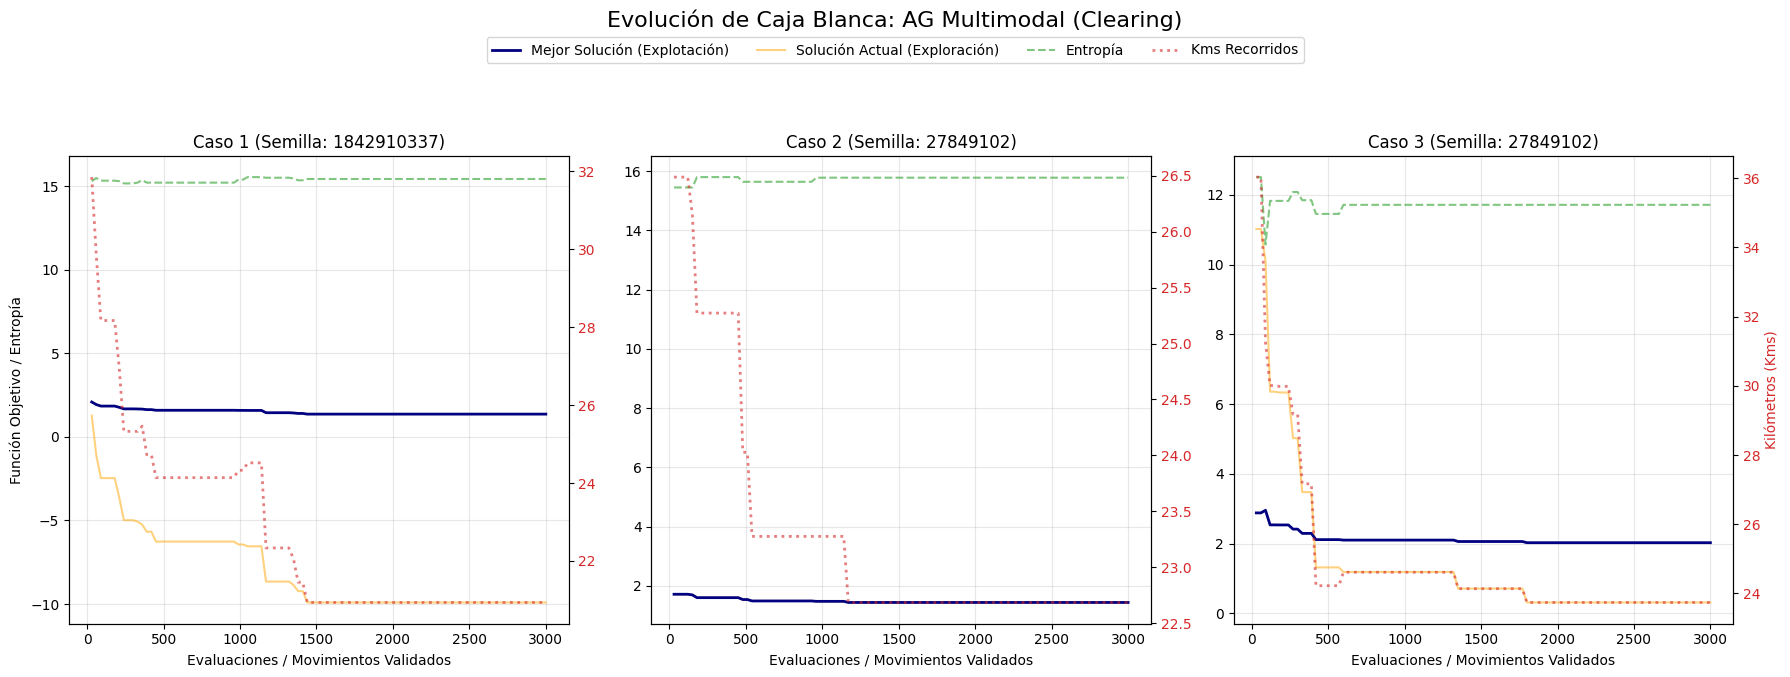

In [7]:
res_multimodal = ejecutar_experimento_ga(
    id_algoritmo='multimodal',
    maps=False
)

### **Tabla 1.2 — Resultados Globales**

Mejor resultado de cada algoritmo y caso (Greedy y P.Mejor reutilizados de la Práctica 1).

In [8]:
generar_tabla_global_p3({
    'Greedy': res_greedy,
    'Primer Mejor': res_primer_mejor,
    'Básico': res_basico,
    'CHC': res_chc,
    'Multimodal': res_multimodal,
})

### **Tabla 1.1 — Resultados Parciales por algoritmo**

Las 5 ejecuciones (una por semilla) por caso con la función objetivo estándar `fobj_ratio`, más Media y Desviación. En negrita, el mejor resultado de cada columna.

In [9]:
_ = ejecutar_tabla_parcial('basico')

In [10]:
_ = ejecutar_tabla_parcial('chc')

In [11]:
_ = ejecutar_tabla_parcial('multimodal')

### **Análisis de Caja Negra y Caja Blanca**

Coeficiente de Variación y RPD (vs. mejor conocido de P1/P2), diversificación estructural por posición y por **arcos**, estudio de convergencia/reinicios de CHC y dinámica de Clearing del Multimodal.


 ANÁLISIS CAJA NEGRA Y BLANCA — ALGORITMOS EVOLUTIVOS (Caso 1)
Ejecutando los 3 AG (5 semillas) con fobj_ratio...

--- 1. MEDIDAS DE CAJA NEGRA (CV, RPD) ---
| Algoritmo  | Media    | Std (σ)  | CV (%)   | RPD (%)  |
-----------------------------------------------------------------
| Básico     | 1.53     | 0.09     | 5.89     | 0.78     |
| CHC        | 1.37     | 0.02     | 1.13     | -0.65    |
| Multimodal | 1.39     | 0.05     | 3.70     | -0.58    |
  ℹ️  RPD negativo detectado vs. fobj_mejor_conocido=1.3665:
     CHC obtiene 1.3576 (RPD=-0.65%) — supera el mejor de P1.
     Multimodal obtiene 1.3585 (RPD=-0.58%) — supera el mejor de P1.
     Se debe documentar la mejora en el informe final.


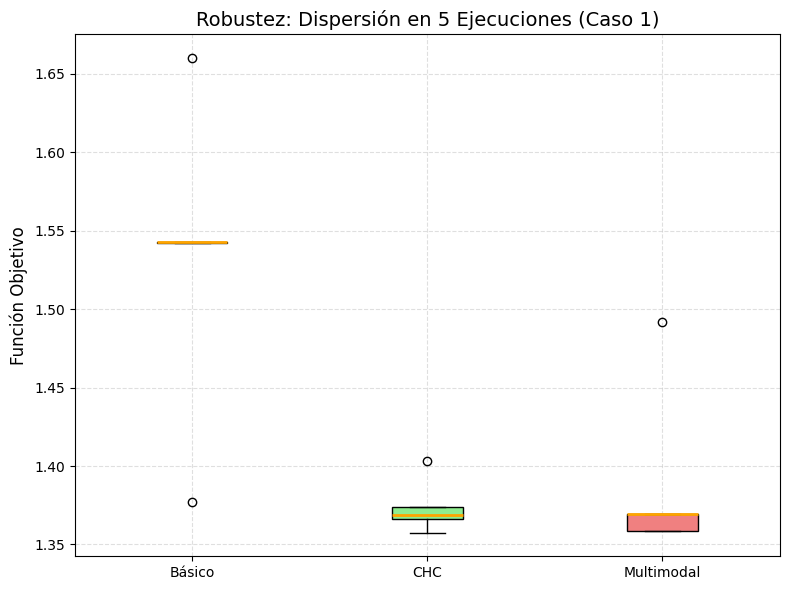


--- 2. MEDIDAS DE CAJA BLANCA ---

[2.1] Diversificación estructural por POSICIÓN (Hamming clásica):
  Básico:
>> Tasa de Overlap en las primeras 4 posiciones: 10.0%
   Buena diversificación. El algoritmo explora topologías estructuralmente distintas.
  CHC:
>> Tasa de Overlap en las primeras 4 posiciones: 10.0%
   Buena diversificación. El algoritmo explora topologías estructuralmente distintas.
  Multimodal:
>> Tasa de Overlap en las primeras 4 posiciones: 22.5%
   Buena diversificación. El algoritmo explora topologías estructuralmente distintas.

[2.2] Diversificación estructural por ARCOS (Hamming de secuencia):
>> Básico Diversificación estructural (arcos distintos): 67.7%
   Buena diversidad: las soluciones recorren tramos distintos.
>> CHC Diversificación estructural (arcos distintos): 73.1%
   Buena diversidad: las soluciones recorren tramos distintos.
>> Multimodal Diversificación estructural (arcos distintos): 54.6%
   Buena diversidad: las soluciones recorren tramos distint

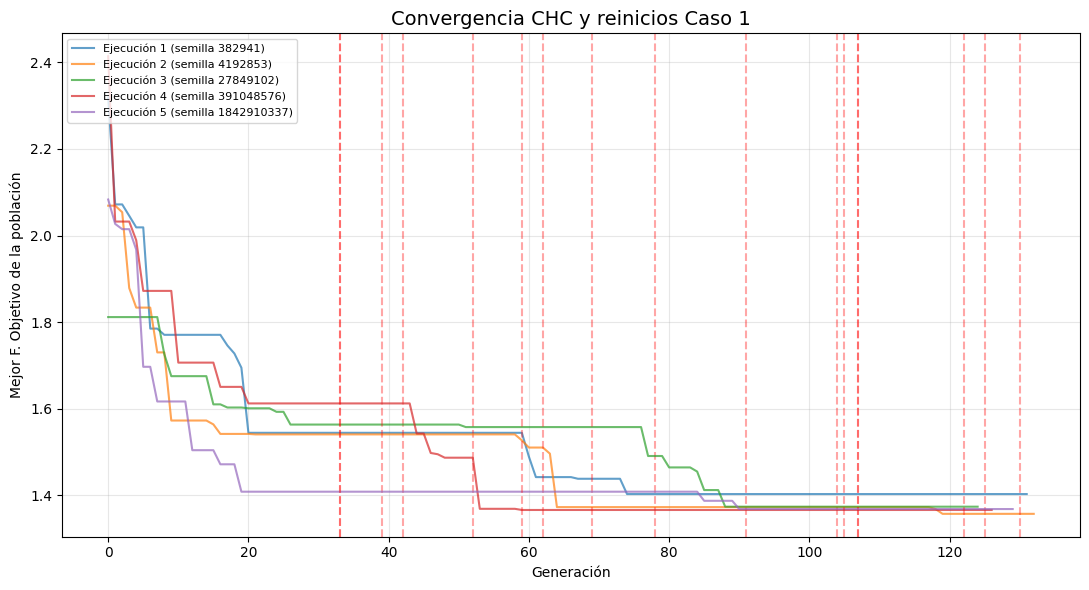

>> Reinicios por ejecución: [3, 4, 3, 3, 4] (media=3.4). El gráfico muestra cómo cada reinicio reinyecta diversidad copiando el mejor y aleatorizando el resto (estrategia de diversidad de CHC: sin mutación, divergencia por reinicio).

[2.3b] Fitness mejor/media/peor de CHC (ejecución representativa):


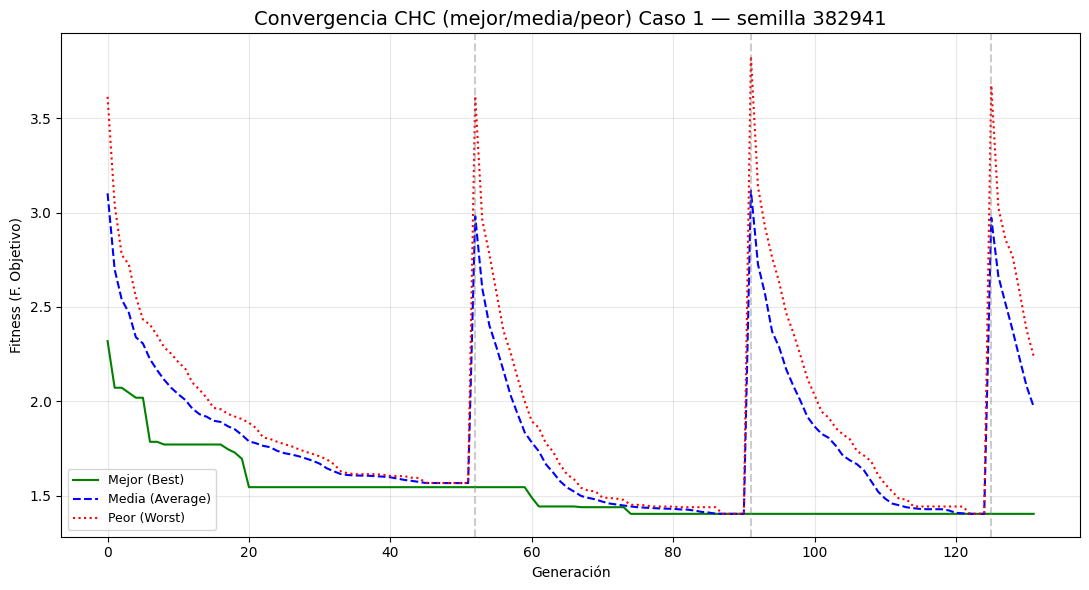


[2.3c] Diversidad genética de CHC (Hamming por arcos normalizada):


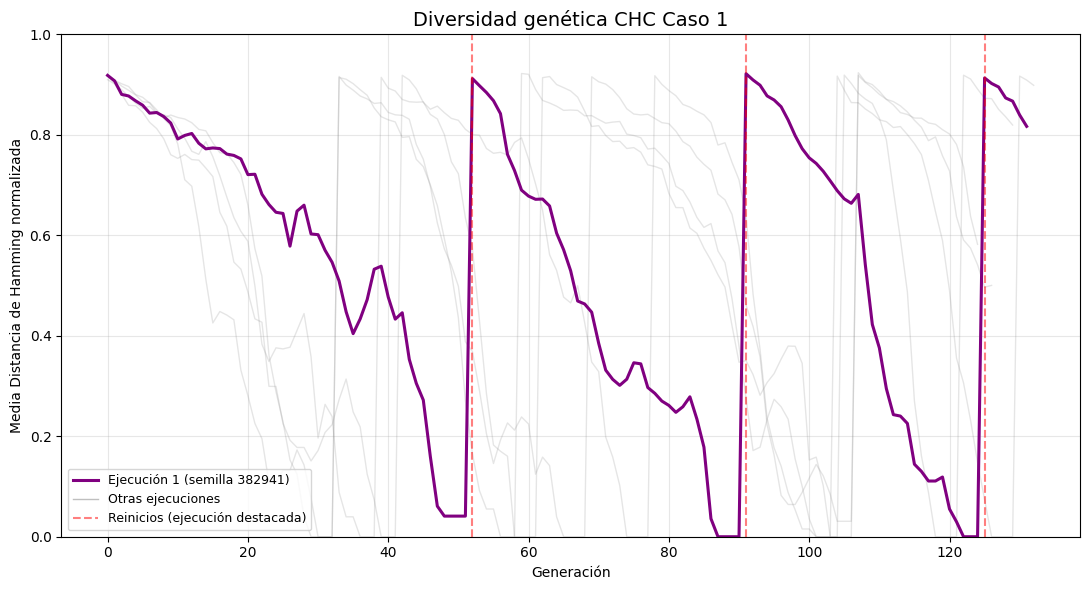

>> Diversidad media en las últimas 10 generaciones: 0.607. Los picos coinciden con los reinicios (reinyección de diversidad sin mutación); el descenso entre reinicios refleja la convergencia por prevención de incesto.

[2.4] Dinámica de Clearing del AG Multimodal:


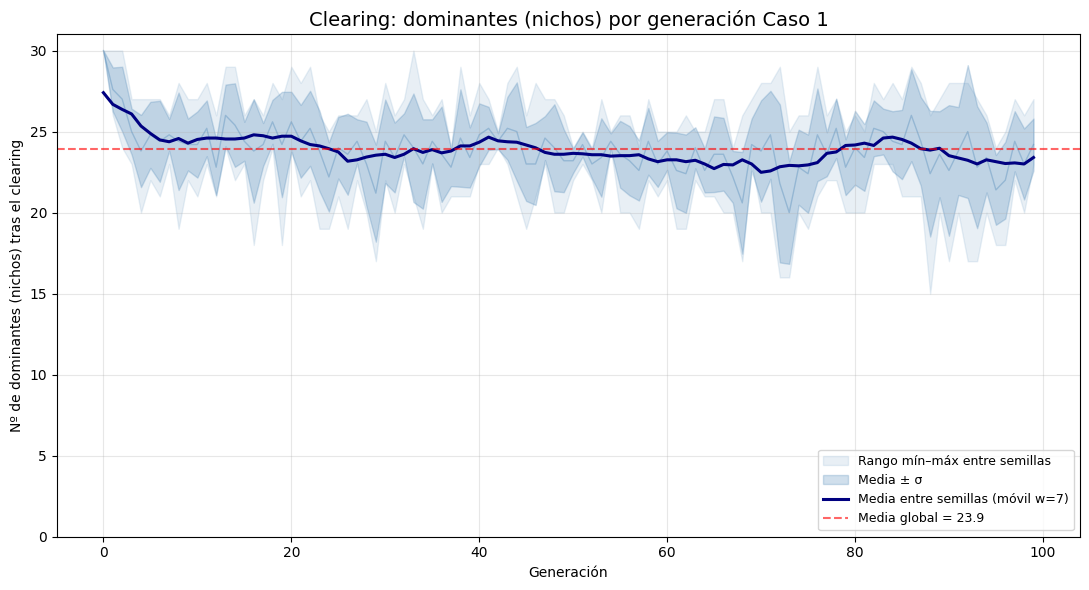

>> Clearing aplicado en 100 generaciones | dominantes: media global=23.9 (rango 15–30) sobre 5 semillas. Un nivel alto y estable indica que la población se reparte de forma sostenida en múltiples nichos estructurales (multimodalidad efectiva); no satura en un único óptimo.

Análisis estadístico finalizado.


In [12]:
ejecutar_analisis_cajas_p3(caso_nombre='Caso 1')


 ANÁLISIS CAJA NEGRA Y BLANCA — ALGORITMOS EVOLUTIVOS (Caso 2)
Ejecutando los 3 AG (5 semillas) con fobj_ratio...

--- 1. MEDIDAS DE CAJA NEGRA (CV, RPD) ---
| Algoritmo  | Media    | Std (σ)  | CV (%)   | RPD (%)  |
-----------------------------------------------------------------
| Básico     | 1.53     | 0.06     | 3.92     | -0.69    |
| CHC        | 1.48     | 0.02     | 1.67     | -0.00    |
| Multimodal | 1.49     | 0.05     | 3.64     | -0.00    |
  ℹ️  RPD negativo detectado vs. fobj_mejor_conocido=1.4377:
     Básico obtiene 1.4277 (RPD=-0.69%) — supera el mejor de P1.
     Se debe documentar la mejora en el informe final.


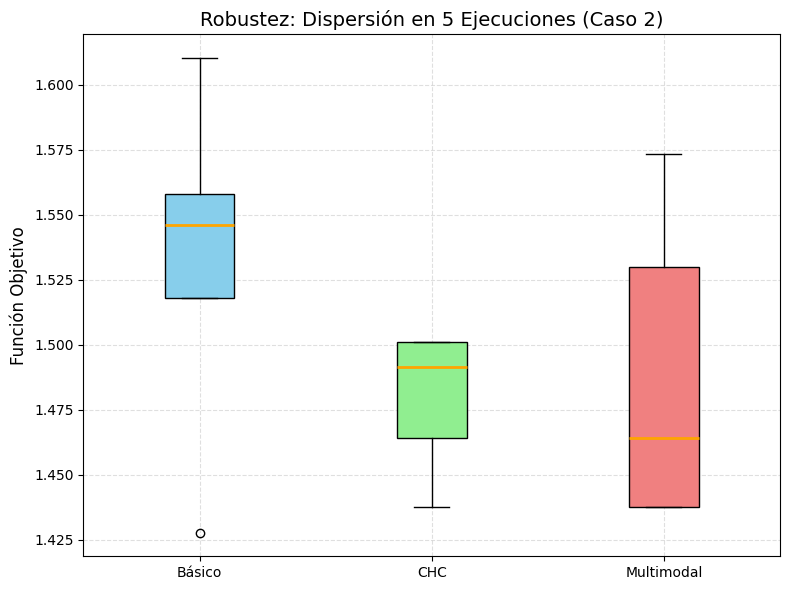


--- 2. MEDIDAS DE CAJA BLANCA ---

[2.1] Diversificación estructural por POSICIÓN (Hamming clásica):
  Básico:
>> Tasa de Overlap en las primeras 4 posiciones: 25.0%
   Buena diversificación. El algoritmo explora topologías estructuralmente distintas.
  CHC:
>> Tasa de Overlap en las primeras 4 posiciones: 17.5%
   Buena diversificación. El algoritmo explora topologías estructuralmente distintas.
  Multimodal:
>> Tasa de Overlap en las primeras 4 posiciones: 27.5%
   Buena diversificación. El algoritmo explora topologías estructuralmente distintas.

[2.2] Diversificación estructural por ARCOS (Hamming de secuencia):
>> Básico Diversificación estructural (arcos distintos): 67.7%
   Buena diversidad: las soluciones recorren tramos distintos.
>> CHC Diversificación estructural (arcos distintos): 62.3%
   Buena diversidad: las soluciones recorren tramos distintos.
>> Multimodal Diversificación estructural (arcos distintos): 59.2%
   Buena diversidad: las soluciones recorren tramos distint

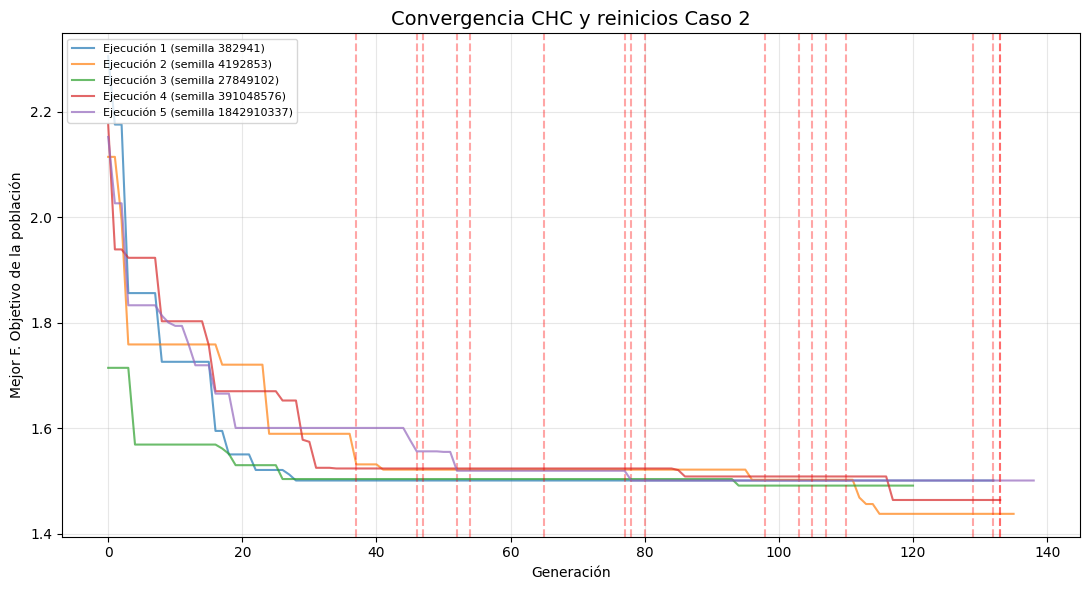

>> Reinicios por ejecución: [3, 4, 3, 4, 4] (media=3.6). El gráfico muestra cómo cada reinicio reinyecta diversidad copiando el mejor y aleatorizando el resto (estrategia de diversidad de CHC: sin mutación, divergencia por reinicio).

[2.3b] Fitness mejor/media/peor de CHC (ejecución representativa):


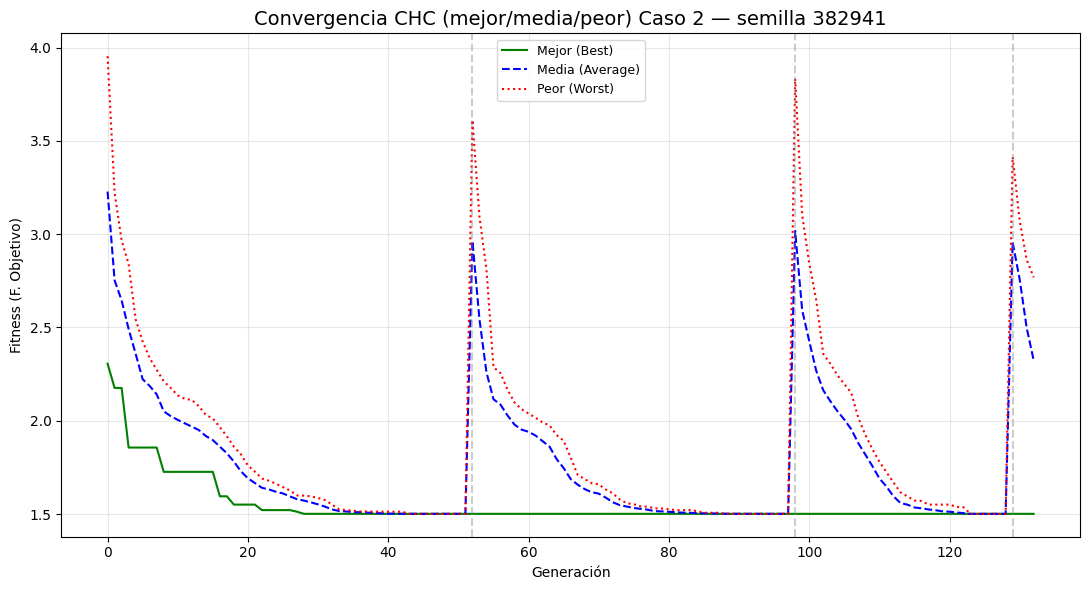


[2.3c] Diversidad genética de CHC (Hamming por arcos normalizada):


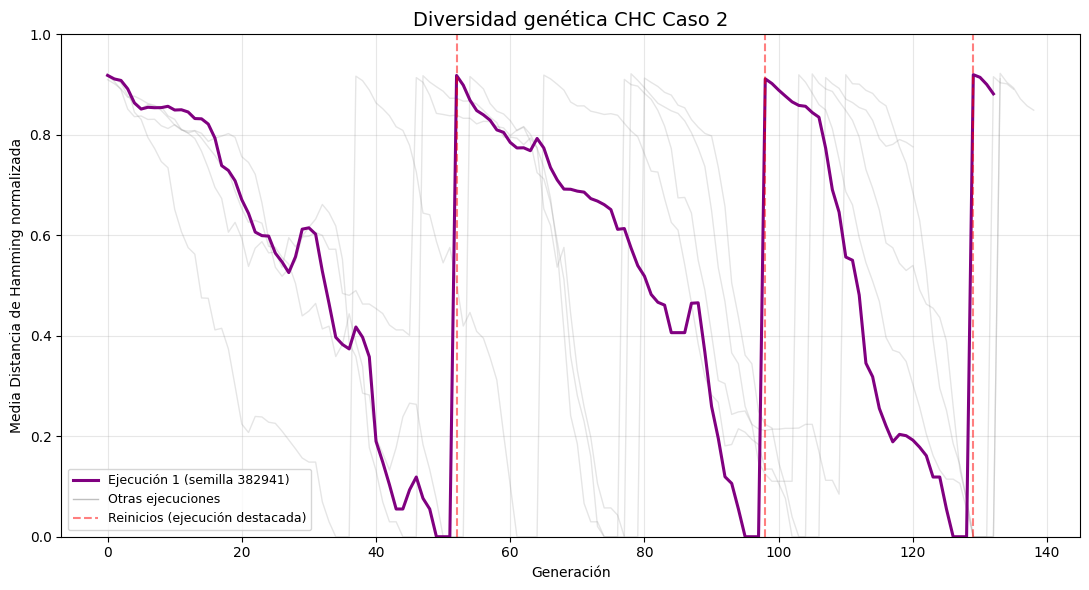

>> Diversidad media en las últimas 10 generaciones: 0.461. Los picos coinciden con los reinicios (reinyección de diversidad sin mutación); el descenso entre reinicios refleja la convergencia por prevención de incesto.

[2.4] Dinámica de Clearing del AG Multimodal:


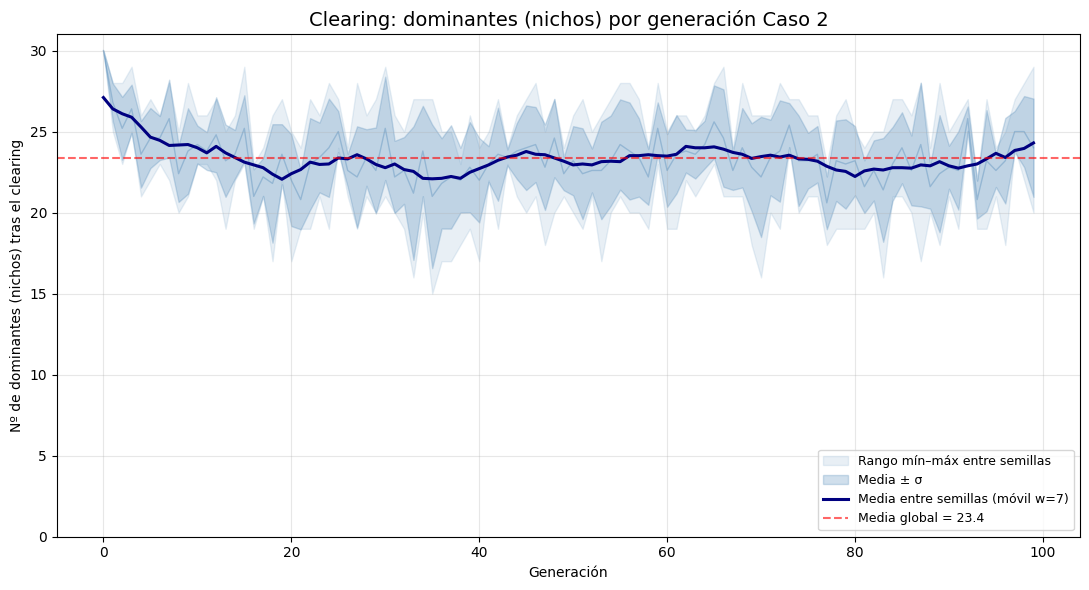

>> Clearing aplicado en 100 generaciones | dominantes: media global=23.4 (rango 15–30) sobre 5 semillas. Un nivel alto y estable indica que la población se reparte de forma sostenida en múltiples nichos estructurales (multimodalidad efectiva); no satura en un único óptimo.

Análisis estadístico finalizado.


In [13]:
ejecutar_analisis_cajas_p3(caso_nombre='Caso 2')


 ANÁLISIS CAJA NEGRA Y BLANCA — ALGORITMOS EVOLUTIVOS (Caso 3)
Ejecutando los 3 AG (5 semillas) con fobj_ratio...

--- 1. MEDIDAS DE CAJA NEGRA (CV, RPD) ---
| Algoritmo  | Media    | Std (σ)  | CV (%)   | RPD (%)  |
-----------------------------------------------------------------
| Básico     | 2.31     | 0.12     | 5.36     | 7.93     |
| CHC        | 2.17     | 0.07     | 3.25     | 1.97     |
| Multimodal | 2.18     | 0.06     | 2.86     | 2.26     |


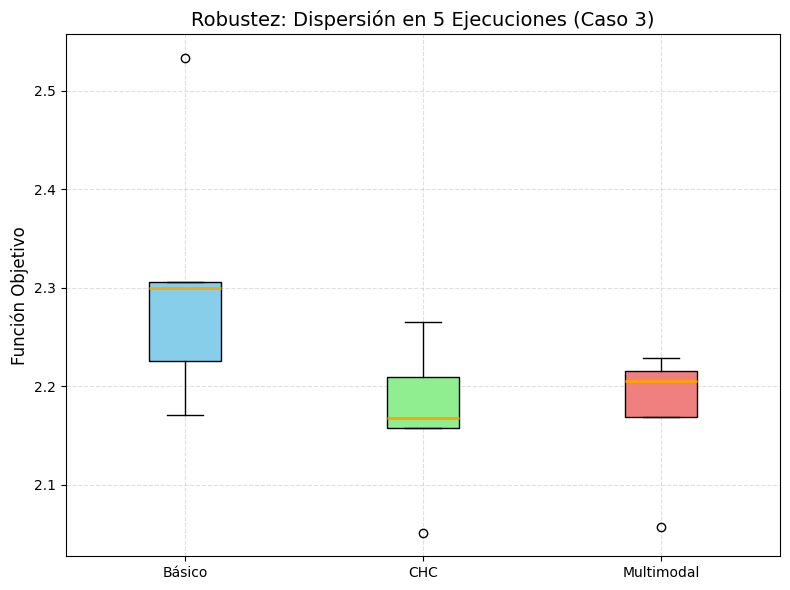


--- 2. MEDIDAS DE CAJA BLANCA ---

[2.1] Diversificación estructural por POSICIÓN (Hamming clásica):
  Básico:
>> Tasa de Overlap en las primeras 4 posiciones: 17.5%
   Buena diversificación. El algoritmo explora topologías estructuralmente distintas.
  CHC:
>> Tasa de Overlap en las primeras 4 posiciones: 12.5%
   Buena diversificación. El algoritmo explora topologías estructuralmente distintas.
  Multimodal:
>> Tasa de Overlap en las primeras 4 posiciones: 32.5%
   Buena diversificación. El algoritmo explora topologías estructuralmente distintas.

[2.2] Diversificación estructural por ARCOS (Hamming de secuencia):
>> Básico Diversificación estructural (arcos distintos): 75.0%
   Buena diversidad: las soluciones recorren tramos distintos.
>> CHC Diversificación estructural (arcos distintos): 72.9%
   Buena diversidad: las soluciones recorren tramos distintos.
>> Multimodal Diversificación estructural (arcos distintos): 70.0%
   Buena diversidad: las soluciones recorren tramos distint

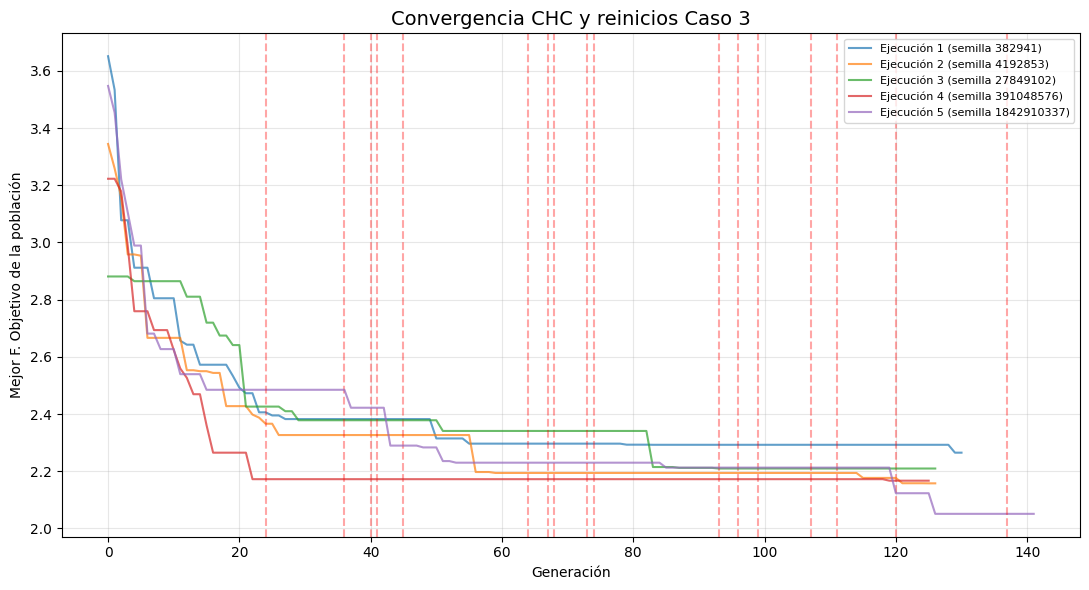

>> Reinicios por ejecución: [4, 3, 3, 3, 4] (media=3.4). El gráfico muestra cómo cada reinicio reinyecta diversidad copiando el mejor y aleatorizando el resto (estrategia de diversidad de CHC: sin mutación, divergencia por reinicio).

[2.3b] Fitness mejor/media/peor de CHC (ejecución representativa):


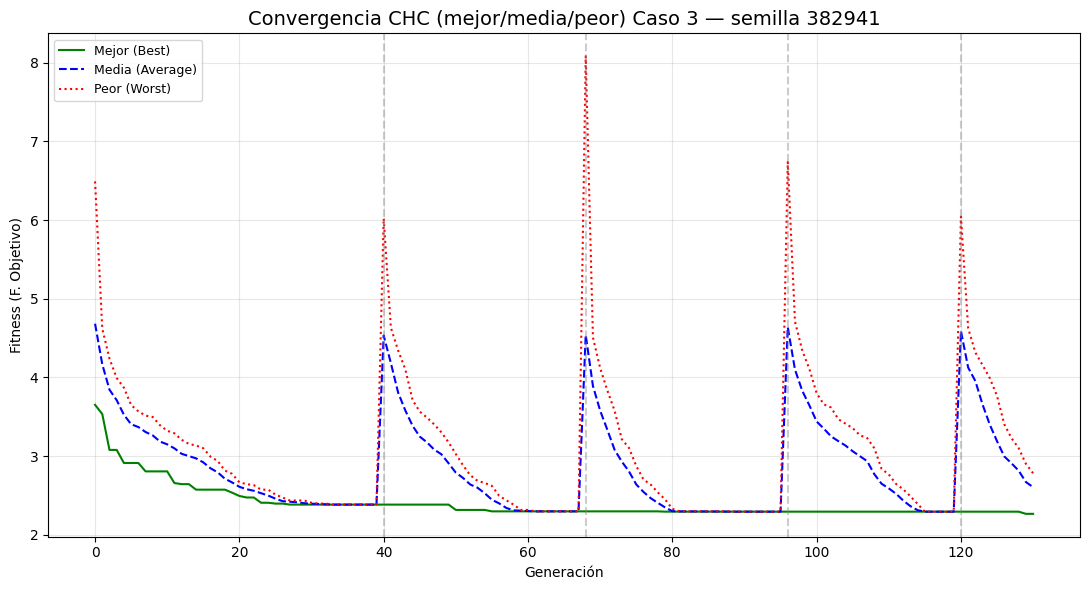


[2.3c] Diversidad genética de CHC (Hamming por arcos normalizada):


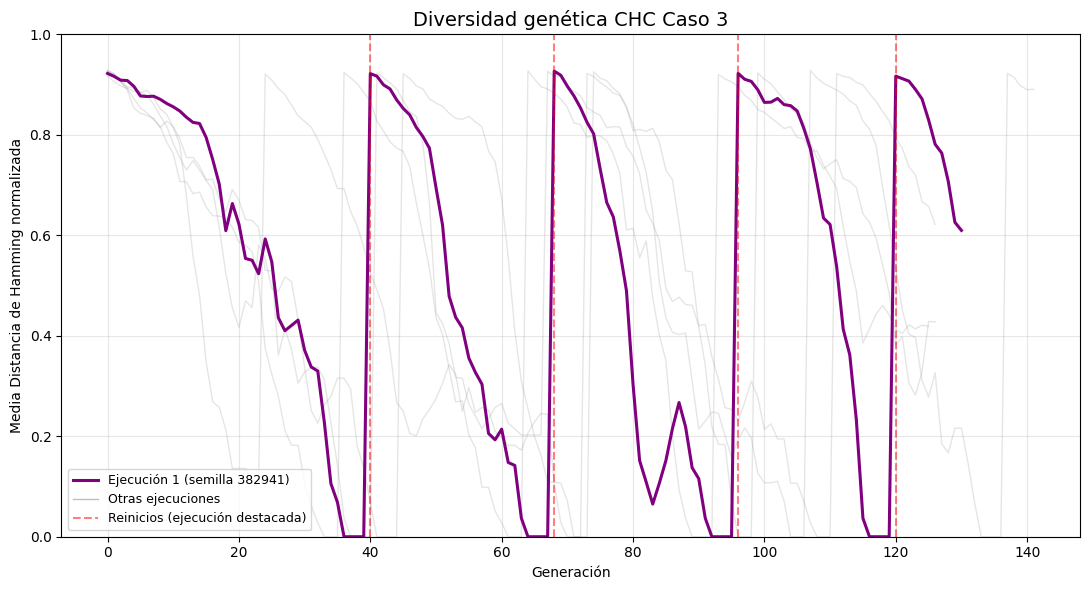

>> Diversidad media en las últimas 10 generaciones: 0.568. Los picos coinciden con los reinicios (reinyección de diversidad sin mutación); el descenso entre reinicios refleja la convergencia por prevención de incesto.

[2.4] Dinámica de Clearing del AG Multimodal:


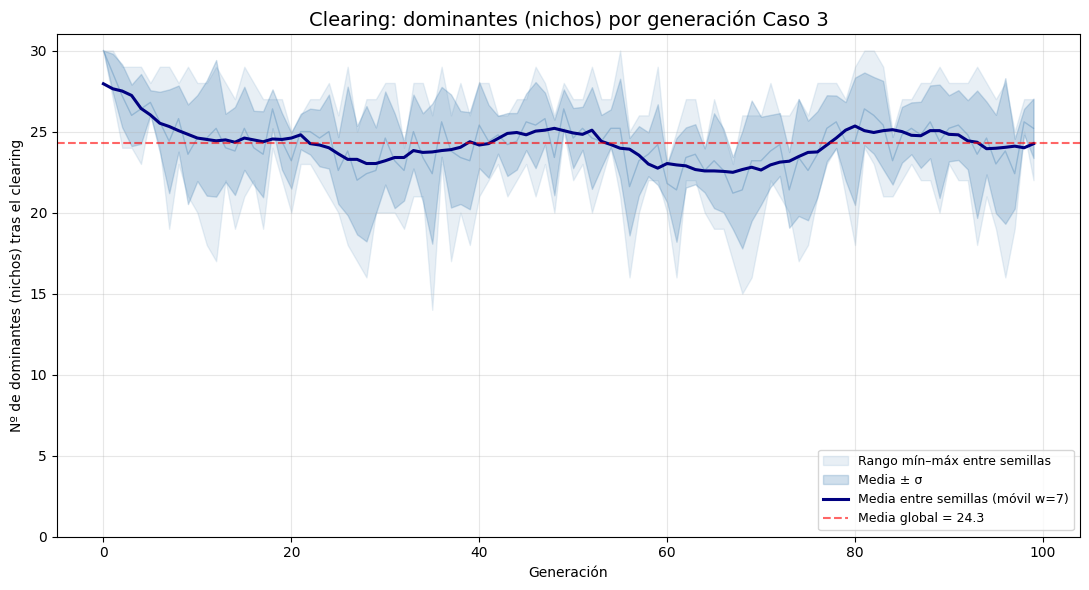

>> Clearing aplicado en 100 generaciones | dominantes: media global=24.3 (rango 14–30) sobre 5 semillas. Un nivel alto y estable indica que la población se reparte de forma sostenida en múltiples nichos estructurales (multimodalidad efectiva); no satura en un único óptimo.

Análisis estadístico finalizado.


In [14]:
ejecutar_analisis_cajas_p3(caso_nombre='Caso 3')

### **Estudio Paramétrico (experimentación para Sobresaliente)**

Barrido de los parámetros clave para justificar las elecciones de diseño como *sweet spot*. Cada valor se evalúa con las 5 semillas sobre el **Caso 1** usando `fobj_ratio` (Media, Mejor, σ, CV). Para el Multimodal y el CHC se añade una métrica de Caja Blanca (dominantes medios / nº de reinicios). Para el AG Básico se incluyen además los dos **estudios opcionales del guion**: modelo poblacional (Generacional vs Estacionario) y elitismo on/off. En negrita, el mejor valor por columna. Valores por defecto: AG Básico K≈10 % (≈3), cruce 90 %, Generacional + elitismo; CHC y Clearing umbral/radio = L/4.

In [15]:
# Multimodal (Clearing): radio del nicho (sigma) y capacidad de nicho
_ = ejecutar_estudio_parametrico('multimodal', 'sigma_clearing', [1, 3, 6], caso_nombre='Caso 1')
_ = ejecutar_estudio_parametrico('multimodal', 'capacidad_nicho', [1, 2, 3], caso_nombre='Caso 1')


 ESTUDIO PARAMÉTRICO — AG Multimodal (Clearing) | parámetro='sigma_clearing' | Caso 1 (L=12)
 - sigma_clearing=1: media=1.3860 best=1.3585 CV=1.42%
 - sigma_clearing=3: media=1.3894 best=1.3585 CV=3.70%
 - sigma_clearing=6: media=1.3833 best=1.3585 CV=1.78%


sigma_clearing,Media F OBJ,Mejor F OBJ,σ,CV (%),Dominantes
1,1.3860,1.3585,0.0197,1.42,25.7
3,1.3894,1.3585,0.0514,3.70,23.9
6,1.3833,1.3585,0.0246,1.78,18.8



 ESTUDIO PARAMÉTRICO — AG Multimodal (Clearing) | parámetro='capacidad_nicho' | Caso 1 (L=12)
 - capacidad_nicho=1: media=1.3894 best=1.3585 CV=3.70%
 - capacidad_nicho=2: media=1.3909 best=1.3585 CV=1.17%
 - capacidad_nicho=3: media=1.4411 best=1.3741 CV=3.46%


capacidad_nicho,Media F OBJ,Mejor F OBJ,σ,CV (%),Dominantes
1,1.3894,1.3585,0.0514,3.70,23.9
2,1.3909,1.3585,0.0163,1.17,24.1
3,1.4411,1.3741,0.0499,3.46,22.9


In [16]:
# CHC: umbral inicial de incesto (por defecto L/4)
_ = ejecutar_estudio_parametrico('chc', 'umbral_ini', [1, 3, 6], caso_nombre='Caso 1')


 ESTUDIO PARAMÉTRICO — AG CHC | parámetro='umbral_ini' | Caso 1 (L=12)
 - umbral_ini=1: media=1.4327 best=1.3576 CV=4.28%
 - umbral_ini=3: media=1.3740 best=1.3576 CV=1.13%
 - umbral_ini=6: media=1.4863 best=1.3772 CV=5.72%


umbral_ini,Media F OBJ,Mejor F OBJ,σ,CV (%),Reinicios
1,1.4327,1.3576,0.0613,4.28,3.8
3,1.3740,1.3576,0.0156,1.13,3.4
6,1.4863,1.3772,0.0850,5.72,2.6


In [17]:
# AG Básico: probabilidad de cruce, presión de torneo (K),
# modelo poblacional (Generacional vs Estacionario) y elitismo on/off
_ = ejecutar_estudio_parametrico('basico', 'prob_cruce', [0.7, 0.9, 1.0], caso_nombre='Caso 1')
_ = ejecutar_estudio_parametrico('basico', 'k_torneo', [2, 3, 6], caso_nombre='Caso 1')
_ = ejecutar_estudio_parametrico('basico', 'modelo', ['generacional', 'estacionario'], caso_nombre='Caso 1')
_ = ejecutar_estudio_parametrico('basico', 'elitismo', [True, False], caso_nombre='Caso 1')


 ESTUDIO PARAMÉTRICO — AG Básico | parámetro='prob_cruce' | Caso 1 (L=12)
 - prob_cruce=0.7: media=1.5925 best=1.5113 CV=3.64%
 - prob_cruce=0.9: media=1.5331 best=1.3772 CV=5.89%
 - prob_cruce=1.0: media=1.5764 best=1.4087 CV=7.11%


prob_cruce,Media F OBJ,Mejor F OBJ,σ,CV (%)
0.7,1.5925,1.5113,0.0580,3.64
0.9,1.5331,1.3772,0.0903,5.89
1.0,1.5764,1.4087,0.1121,7.11



 ESTUDIO PARAMÉTRICO — AG Básico | parámetro='k_torneo' | Caso 1 (L=12)
 - k_torneo=2: media=1.4532 best=1.3927 CV=2.85%
 - k_torneo=3: media=1.5331 best=1.3772 CV=5.89%
 - k_torneo=6: media=1.6690 best=1.5966 CV=5.04%


k_torneo,Media F OBJ,Mejor F OBJ,σ,CV (%)
2,1.4532,1.3927,0.0414,2.85
3,1.5331,1.3772,0.0903,5.89
6,1.6690,1.5966,0.0841,5.04



 ESTUDIO PARAMÉTRICO — AG Básico | parámetro='modelo' | Caso 1 (L=12)
 - modelo=generacional: media=1.5331 best=1.3772 CV=5.89%
 - modelo=estacionario: media=1.6993 best=1.5810 CV=9.25%


modelo,Media F OBJ,Mejor F OBJ,σ,CV (%)
generacional,1.5331,1.3772,0.0903,5.89
estacionario,1.6993,1.5810,0.1573,9.25



 ESTUDIO PARAMÉTRICO — AG Básico | parámetro='elitismo' | Caso 1 (L=12)
 - elitismo=True: media=1.5331 best=1.3772 CV=5.89%
 - elitismo=False: media=1.5704 best=1.3731 CV=11.29%


elitismo,Media F OBJ,Mejor F OBJ,σ,CV (%)
True,1.5331,1.3772,0.0903,5.89
False,1.5704,1.3731,0.1773,11.29


### **Soluciones Multimodales en el Mapa (Caja Blanca opcional)**

Para una única ejecución del AG Multimodal se muestran las mejores soluciones de varios nichos **estructuralmente distintos** (separados por más del radio σ en distancia de Hamming por arcos), con su F. Objetivo, kms y entropía, y su representación en el mapa. Evidencia que el Clearing conserva varios óptimos diferentes a la vez.

In [18]:
_ = mostrar_soluciones_multimodal(caso_nombre='Caso 1', semilla=382941, k=3)


 SOLUCIONES MULTIMODALES (nichos distintos) — Caso 1 | semilla 382941 | 3 nichos

>> Nicho 1: F.Obj(ratio)=1.4918 | Kms=22.88 | Entropía=15.3395



>> Nicho 2: F.Obj(ratio)=1.5486 | Kms=23.61 | Entropía=15.2464



>> Nicho 3: F.Obj(ratio)=1.7536 | Kms=27.25 | Entropía=15.5419
